# Insurance Risk Analytics

## Exploratory Data Analysis

### Business Objective

The objective of this analysis is to explore historical insurance policy and claims data to understand customer risk, profitability, and data quality. The findings from this analysis will guide hypothesis testing and predictive modeling for risk-based pricing.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
pd._config.config.register_option('mode.use_inf_as_null', False)
pd._config.config._global_config['mode.use_inf_as_null'] = False
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from pathlib import Path

import sys

sys.path.append("../")

from src.config import DATA_PATH
from src.data_loader import load_data, preprocess_data

In [2]:
from src.eda_utils import (
    summarize_data,
    check_missing_values,
    numerical_summary,
    categorical_summary,
)

In [3]:
df = load_data(DATA_PATH)

df = preprocess_data(df)

In [4]:
df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [5]:
df.columns

Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims'],
      dtype='object')

In [6]:
len(df.columns)

52

In [7]:
from src.eda_utils import summarize_data

summarize_data(df)


DATASET SHAPE
(1000098, 52)


DATA TYPES
UnderwrittenCoverID                  int64
PolicyID                             int64
TransactionMonth            datetime64[ns]
IsVATRegistered                       bool
Citizenship                         object
LegalType                           object
Title                               object
Language                            object
Bank                                object
AccountType                         object
MaritalStatus                       object
Gender                              object
Country                             object
Province                            object
PostalCode                           int64
MainCrestaZone                      object
SubCrestaZone                       object
ItemType                            object
mmcode                             float64
VehicleType                         object
RegistrationYear                     int64
make                                object
Model        

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
UnderwrittenCoverID,1000098.0,NaN,NaN,NaN,104817.546075,1.0,55143.0,94083.0,139190.0,301175.0,63293.708455
PolicyID,1000098.0,NaN,NaN,NaN,7956.68245,14.0,4500.0,7071.0,11077.0,23246.0,5290.03851
TransactionMonth,1000098,NaN,NaN,NaN,2015-02-28 10:49:29.147423744,2013-10-01 00:00:00,2015-01-01 00:00:00,2015-04-01 00:00:00,2015-06-01 00:00:00,2015-08-01 00:00:00,NaN
IsVATRegistered,1000098,2,False,995075,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Citizenship,1000098,4,,895210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LegalType,1000098,6,Individual,911929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,1000098,5,Mr,933555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Language,1000098,1,English,1000098,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bank,854137,11,First National Bank,260811,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountType,959866,3,Current account,597938,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
from src.eda_utils import check_missing_values

missing_report = check_missing_values(df)

missing_report.head(20)

Duplicate Rows: 0


,Missing Values,Percentage
NumberOfVehiclesInFleet,1000098,100.00
CrossBorder,999400,99.93
CustomValueEstimate,779642,77.96
Rebuilt,641901,64.18
Converted,641901,64.18
WrittenOff,641901,64.18
NewVehicle,153295,15.33
Bank,145961,14.59
AccountType,40232,4.02
Gender,9536,0.95


In [9]:
numerical_summary(df)

,count,mean,min,25%,50%,75%,max,std
UnderwrittenCoverID,1000098.0,104817.546075,1.0,55143.0,94083.0,139190.0,301175.0,63293.708455
PolicyID,1000098.0,7956.68245,14.0,4500.0,7071.0,11077.0,23246.0,5290.03851
TransactionMonth,1000098,2015-02-28 10:49:29.147423744,2013-10-01 00:00:00,2015-01-01 00:00:00,2015-04-01 00:00:00,2015-06-01 00:00:00,2015-08-01 00:00:00,NaN
PostalCode,1000098.0,3020.600887,1.0,827.0,2000.0,4180.0,9870.0,2649.854413
mmcode,999546.0,54877704.020474,4041200.0,60056925.0,60058415.0,60058418.0,65065350.0,13603805.343555
RegistrationYear,1000098.0,2010.225371,1987.0,2008.0,2011.0,2013.0,2015.0,3.261391
Cylinders,999546.0,4.046642,0.0,4.0,4.0,4.0,10.0,0.29402
cubiccapacity,999546.0,2466.743258,0.0,2237.0,2694.0,2694.0,12880.0,442.80064
kilowatts,999546.0,97.207919,0.0,75.0,111.0,111.0,309.0,19.393256
NumberOfDoors,999546.0,4.01925,0.0,4.0,4.0,4.0,6.0,0.468314


In [10]:
categorical_summary(df)

,count,unique,top,freq
Citizenship,1000098,4,,895210
LegalType,1000098,6,Individual,911929
Title,1000098,5,Mr,933555
Language,1000098,1,English,1000098
Bank,854137,11,First National Bank,260811
AccountType,959866,3,Current account,597938
MaritalStatus,991839,3,Not specified,986208
Gender,990562,3,Not specified,940990
Country,1000098,1,South Africa,1000098
Province,1000098,9,Gauteng,393865


# Univariate Analysis

In [11]:
import importlib
import src.eda_utils
importlib.reload(src.eda_utils)

from src.eda_utils import (
    plot_numeric_distribution,
    plot_categorical_distribution,
)

### Numerical Variables

In [12]:
numeric_columns = [
    "TotalPremium",
    "TotalClaims",
    "CustomValueEstimate",
]

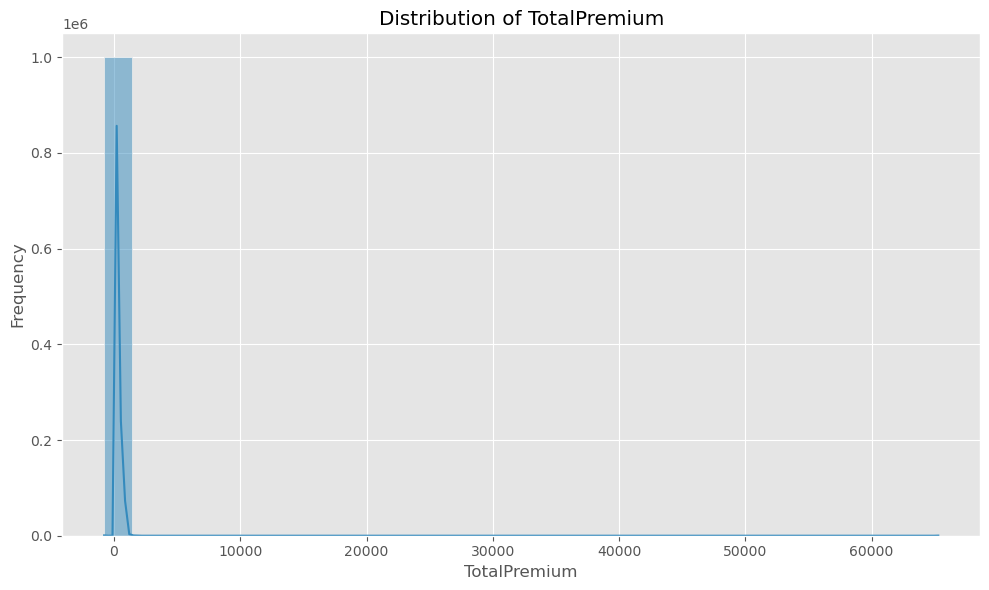

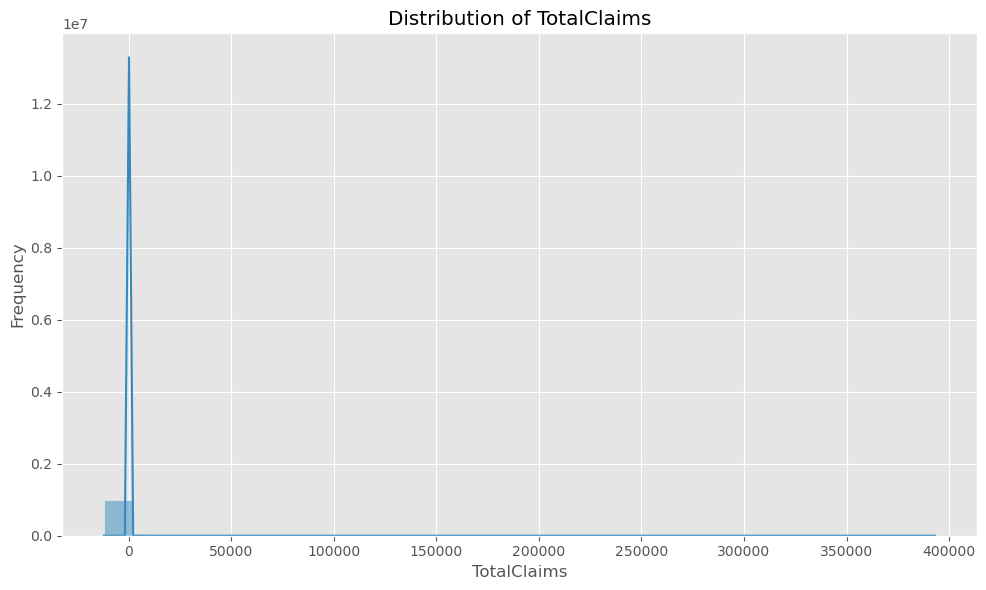

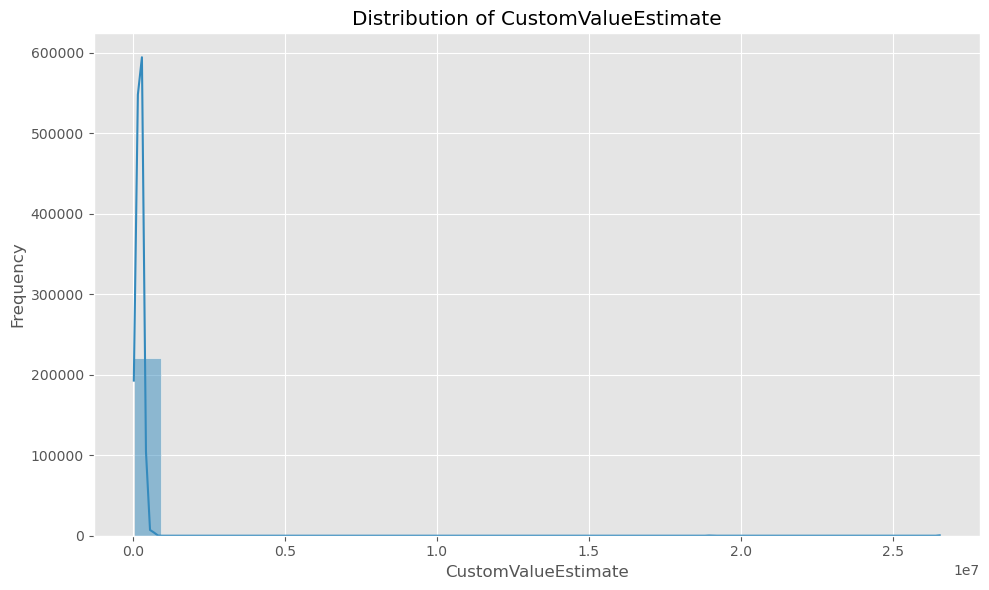

In [13]:
for column in numeric_columns:
    plot_numeric_distribution(df, column)

### Categorical Variables

In [14]:
categorical_columns = [
    "Province",
    "VehicleType",
    "Gender",
    "CoverType",
    "make",
]

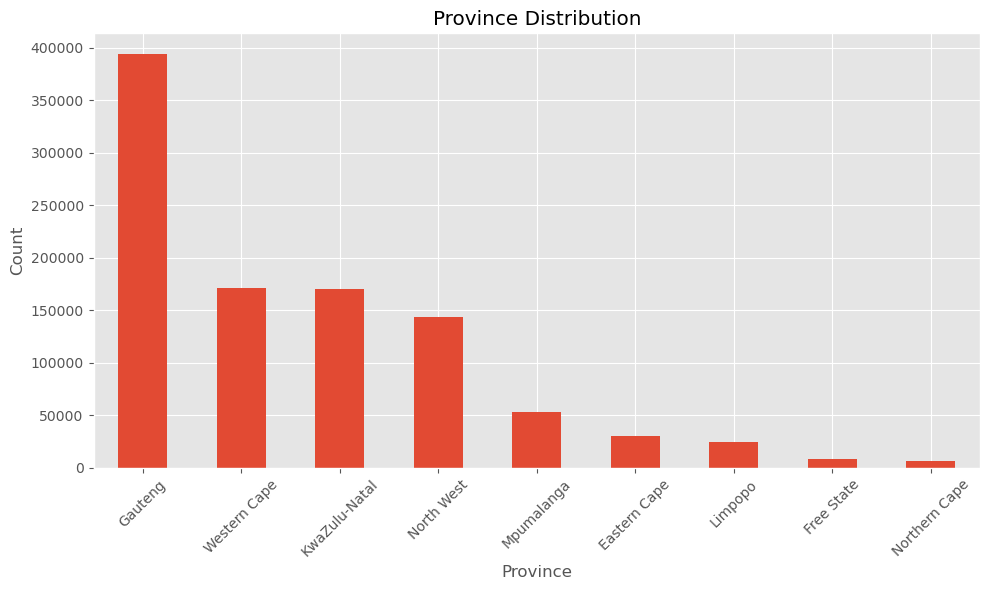

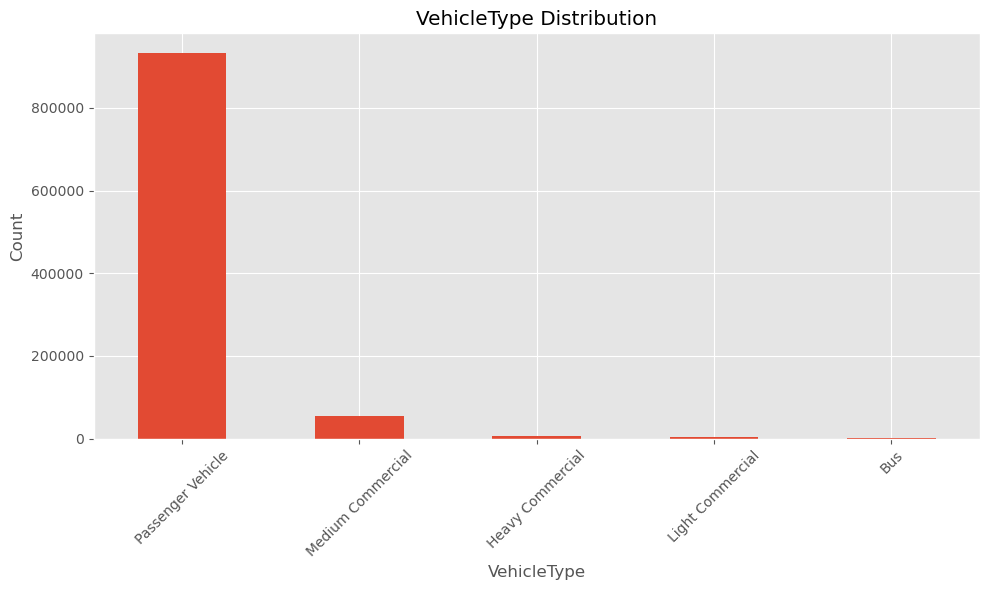

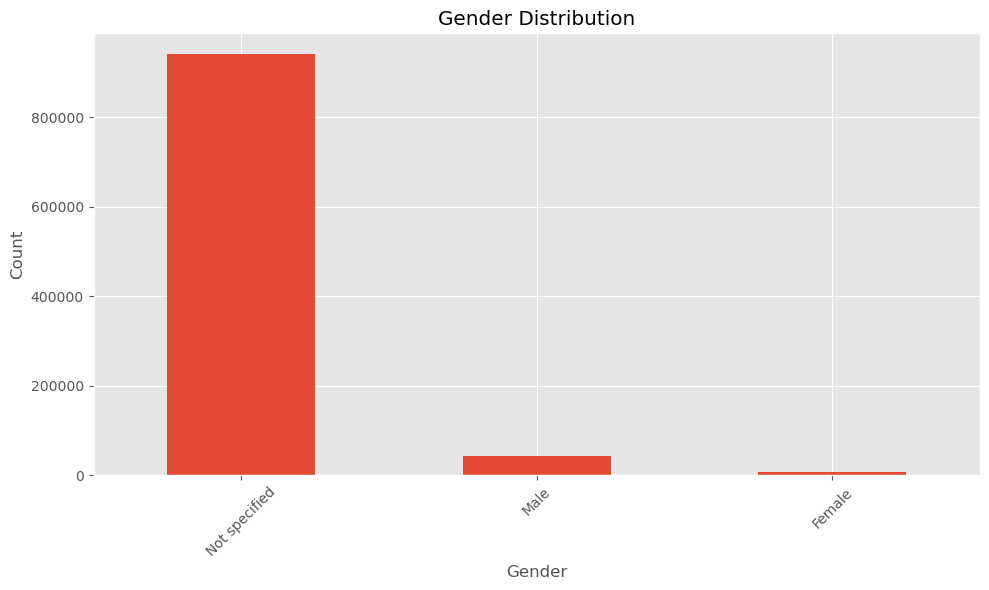

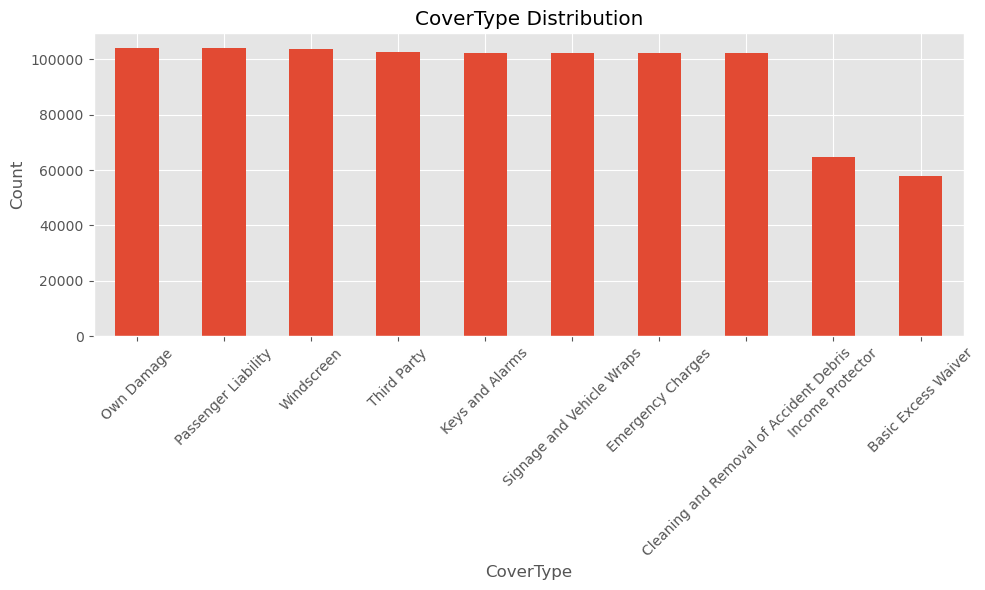

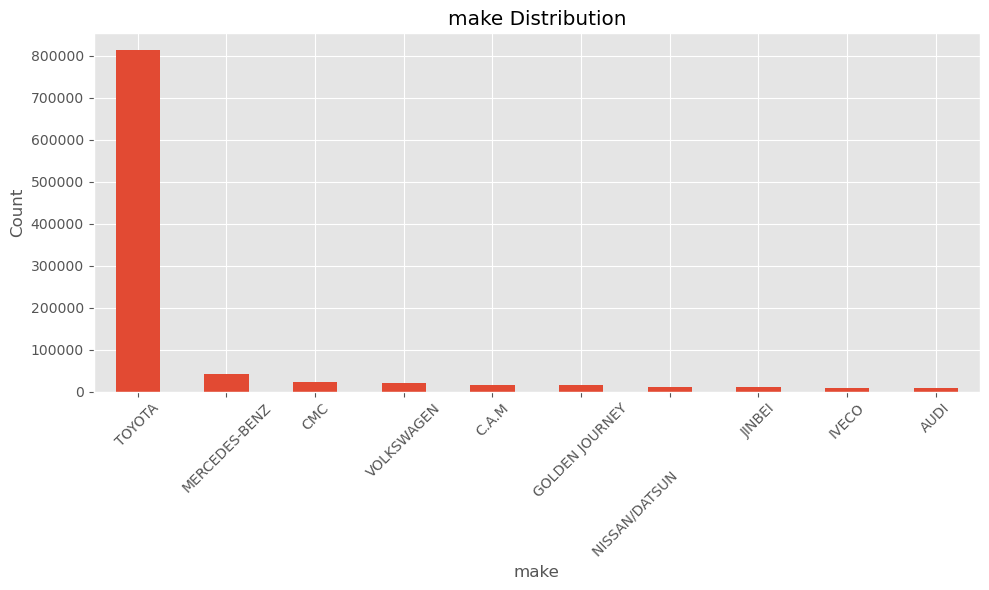

In [15]:
for column in categorical_columns:
    plot_categorical_distribution(df, column)

# Bivariate & Multivariate Analysis

In [16]:
from src.eda_utils import (
    plot_correlation_matrix,
    plot_scatter,
)

### Correlation Matrix

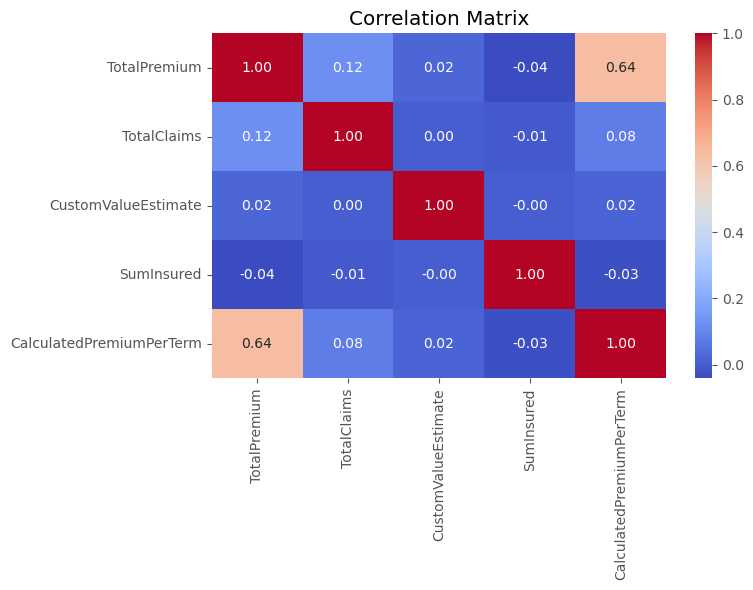

In [17]:
correlation_columns = [
    "TotalPremium",
    "TotalClaims",
    "CustomValueEstimate",
    "SumInsured",
    "CalculatedPremiumPerTerm"
]

plot_correlation_matrix(df, correlation_columns)

### Scatter Plot

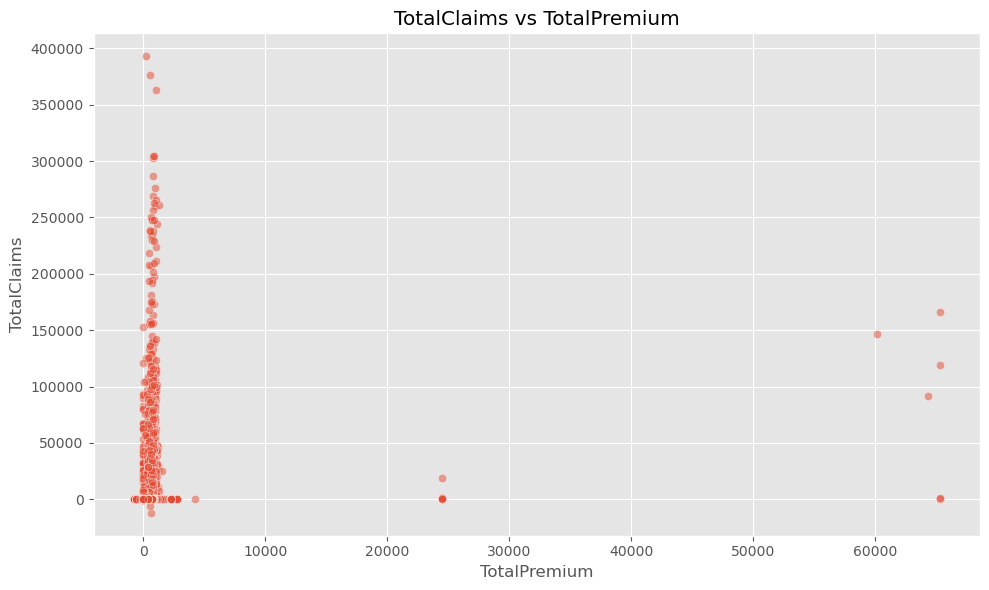

In [18]:
plot_scatter(
    df,
    x="TotalPremium",
    y="TotalClaims"
)

## Business Interpretation

The correlation matrix helps identify linear relationships among key financial variables. The scatter plot shows how claim amounts relate to premiums. Any visible clustering, weak relationships, or extreme claim values may indicate different customer risk profiles that warrant further investigation.

In [19]:
from src.eda_utils import (
    plot_average_by_category,
    plot_top_categories,
)

### Premium by Province

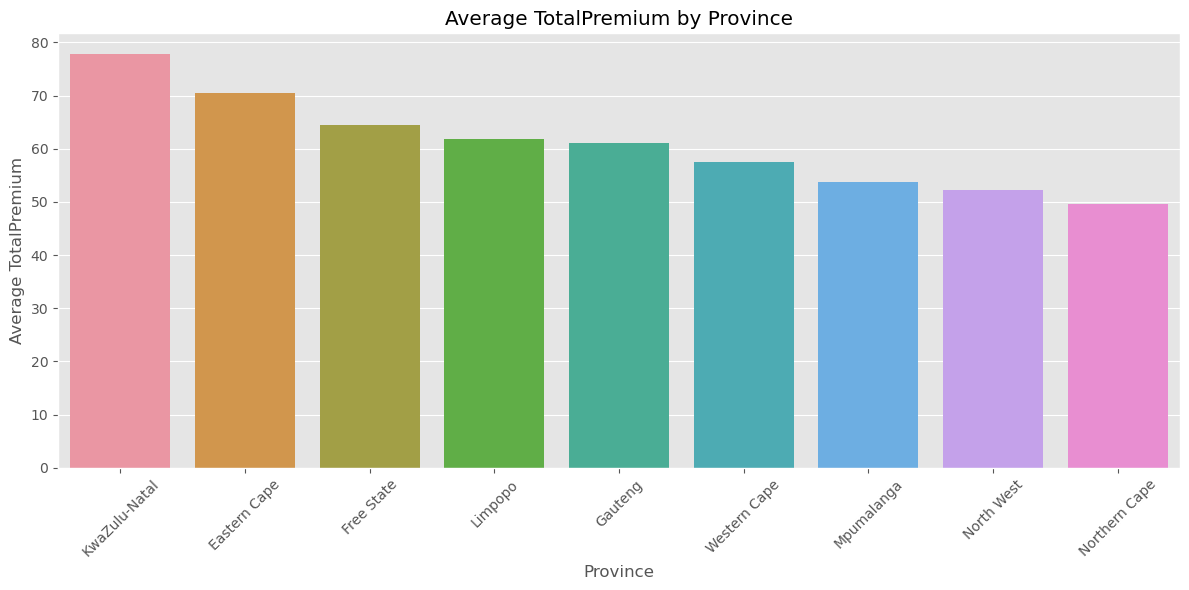

In [20]:
plot_average_by_category(
    df,
    category="Province",
    value="TotalPremium"
)

### Claims by Province

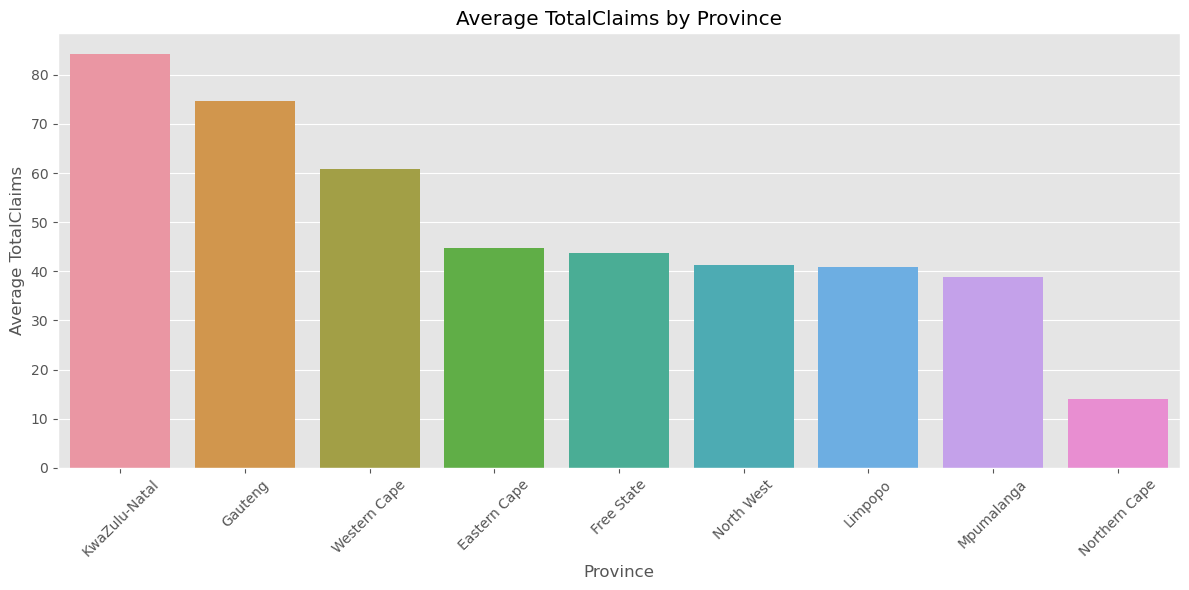

In [21]:
plot_average_by_category(
    df,
    category="Province",
    value="TotalClaims"
)

### Vehicle Makes

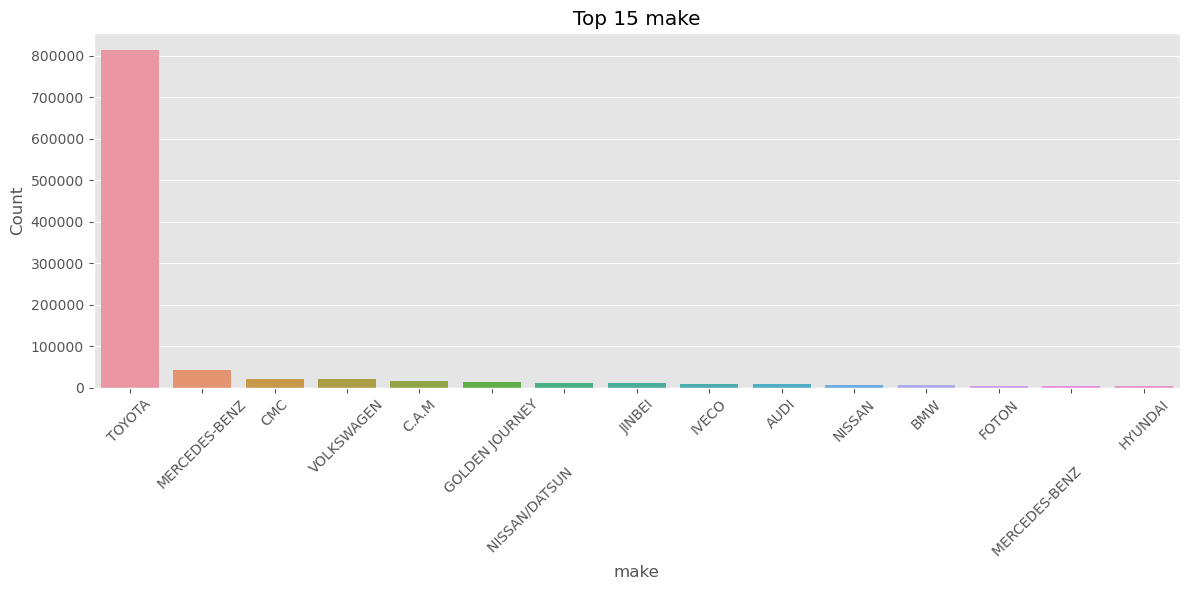

In [22]:
plot_top_categories(
    df,
    category="make",
    top_n=15
)

### Cover Types

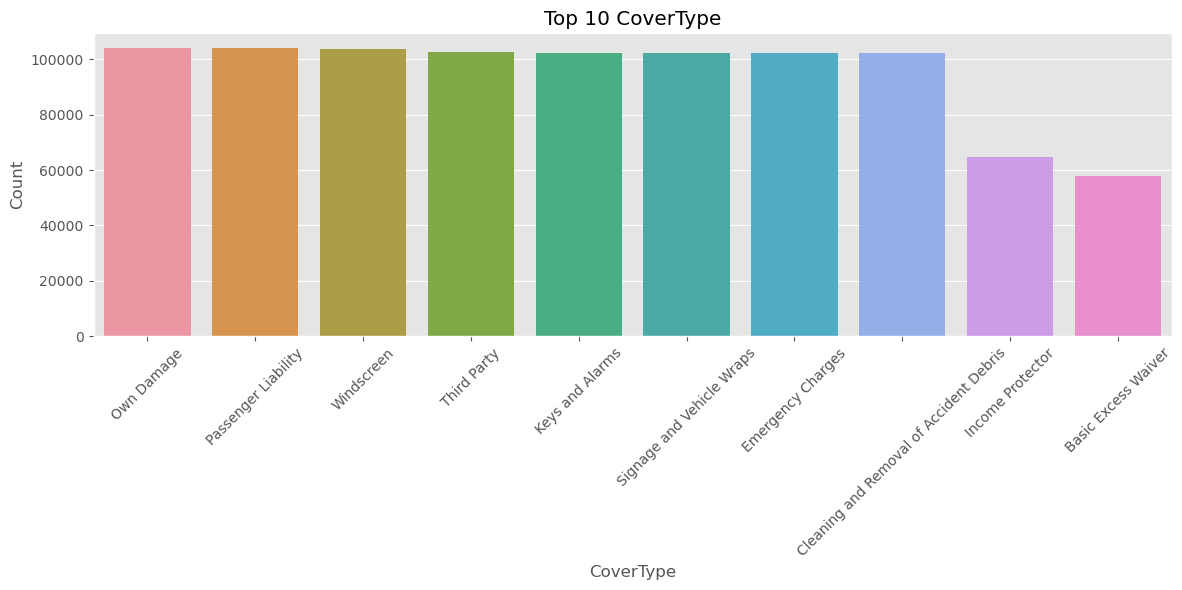

In [23]:
plot_top_categories(
    df,
    category="CoverType",
    top_n=10
)

## Business Interpretation

Geographic analysis helps identify differences in insurance risk across provinces. Comparing average premiums and claim amounts highlights regions with potentially higher exposure or pricing differences. Examining the distribution of vehicle makes and cover types provides additional context about the customer portfolio and may explain variations in claim experience.

### Outlier Detection

In [24]:
from src.eda_utils import plot_boxplot

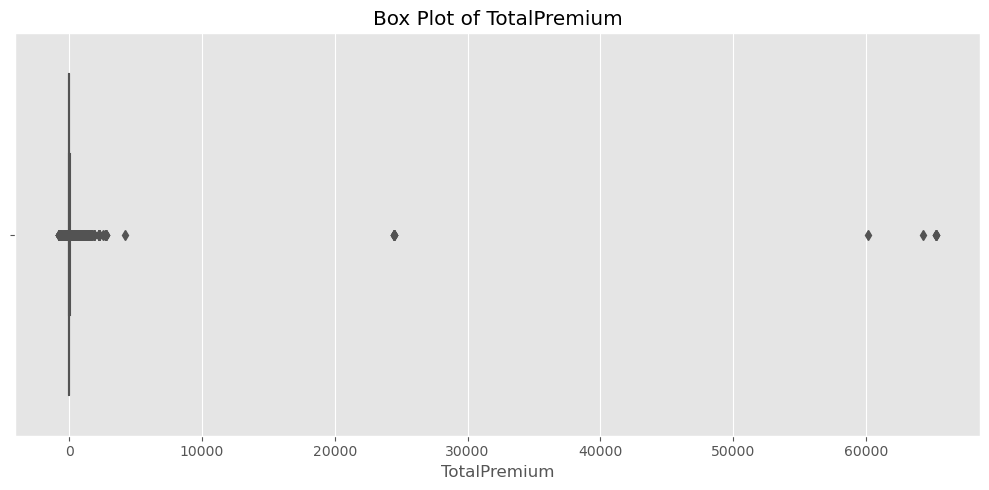

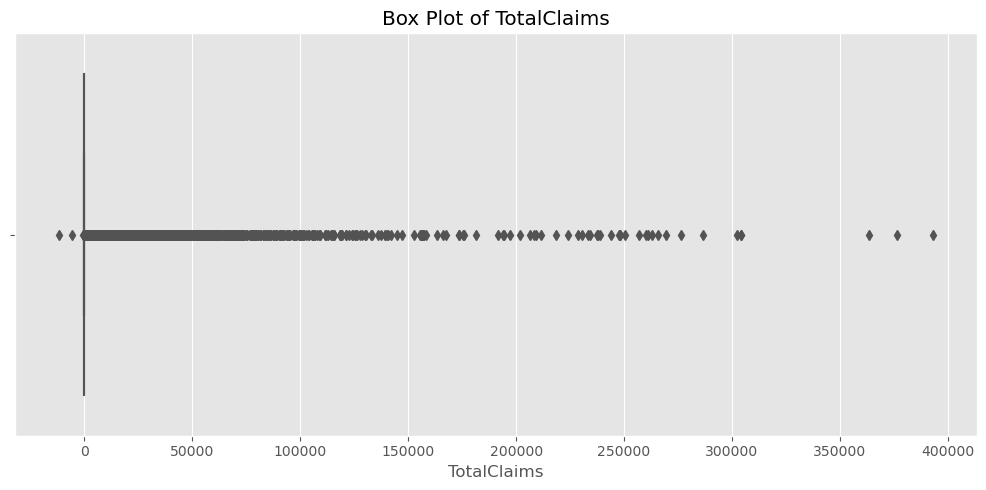

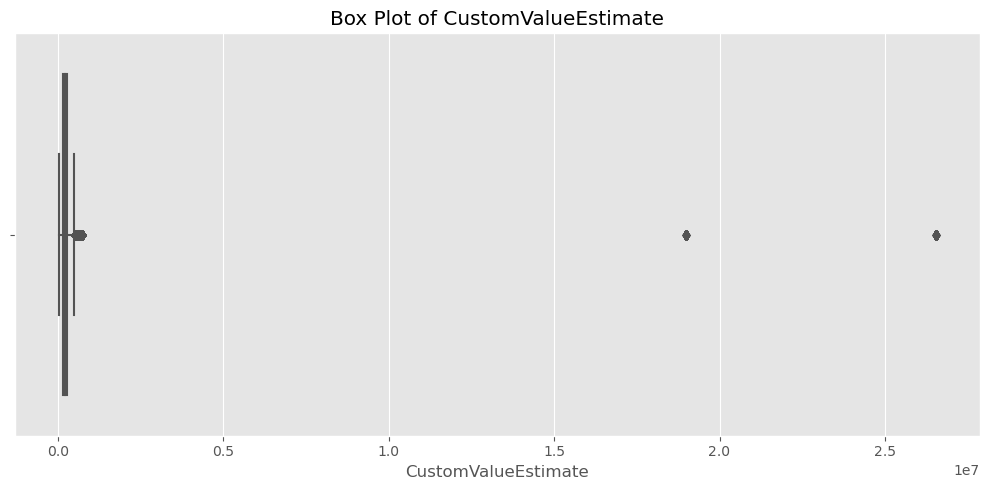

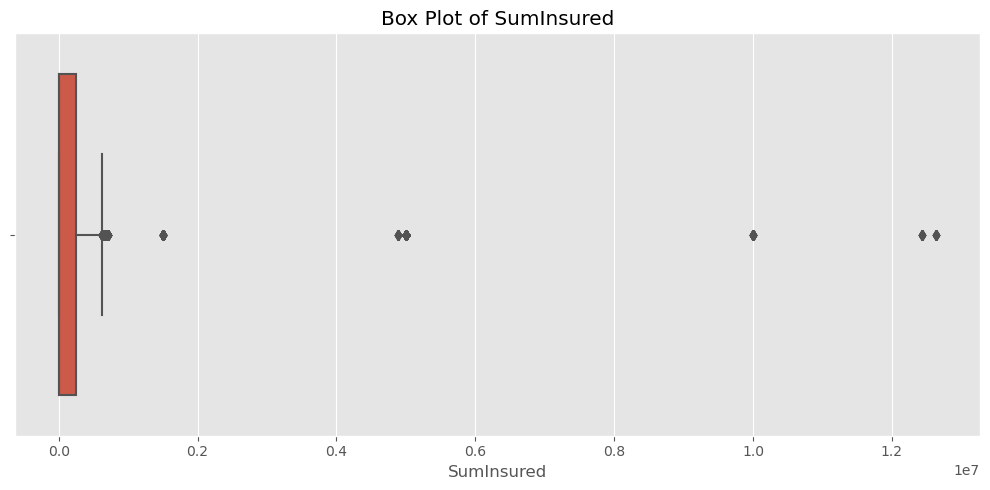

In [25]:
outlier_columns = [
    "TotalPremium",
    "TotalClaims",
    "CustomValueEstimate",
    "SumInsured"
]

for column in outlier_columns:
    plot_boxplot(df, column)

## Business Interpretation

The box plots reveal the presence of extreme values in financial variables such as claim amounts and insured values. These outliers may represent high-risk policies or rare claim events. They should be investigated further because they can influence statistical analyses and predictive models.

### Overall Loss Ratio

In [26]:
overall_loss_ratio = calculate_loss_ratio(df)

print(f"Overall Loss Ratio: {overall_loss_ratio:.2%}")

NameError: name 'calculate_loss_ratio' is not defined

### Province Loss Ration

In [ ]:
province_loss_ratio = loss_ratio_by_group(
    df,
    "Province"
)

province_loss_ratio

### Vehicle Type Loss Ratio

In [ ]:
vehicle_loss_ratio = loss_ratio_by_group(
    df,
    "VehicleType"
)

vehicle_loss_ratio

### Gender Loss Ratio

In [ ]:
gender_loss_ratio = loss_ratio_by_group(
    df,
    "Gender"
)

gender_loss_ratio

## Business Interpretation 

The loss ratio measures the proportion of premiums paid out as claims. Higher loss ratios indicate lower profitability, while lower ratios suggest more profitable customer segments. Comparing loss ratios across provinces, vehicle types, and gender helps identify groups that may require pricing adjustments or further investigation.

### Temporal Trends

In [ ]:
monthly = monthly_claim_trend(df)

monthly.head()

### Plot Premium vs Claims

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly["TransactionMonth"],
    monthly["TotalPremium"],
    label="Premium"
)

plt.plot(
    monthly["TransactionMonth"],
    monthly["TotalClaims"],
    label="Claims"
)

plt.title("Monthly Premium and Claims")

plt.xlabel("Month")

plt.ylabel("Amount")

plt.legend()

plt.tight_layout()

plt.show()

### Plot Claim Frequency

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly["TransactionMonth"],
    monthly["ClaimCount"]
)

plt.title("Monthly Claim Frequency")

plt.xlabel("Month")

plt.ylabel("Number of Claims")

plt.tight_layout()

plt.show()

### Vehicle Makes

In [ ]:
make_claims = vehicle_claim_summary(df, "make")

display(make_claims.head(10))

display(make_claims.tail(10))

### Vehicle Models

In [ ]:
model_claims = vehicle_claim_summary(df, "Model")

display(model_claims.head(10))

display(model_claims.tail(10))